In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time
import os

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Data Loading and Temporal Structuring

In [ ]:
DATA_URL = "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv?download=true"
TARGET_COLUMN = "Label"
NORMAL_LABEL = "BENIGN"

print("Loading dataset...")
df = pd.read_csv(DATA_URL)

df.columns = df.columns.astype(str).str.strip()

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"Target column {TARGET_COLUMN!r} was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.strip().str.upper()
y = (df[TARGET_COLUMN] != NORMAL_LABEL).astype("int32")

X = df.drop(columns=[TARGET_COLUMN], errors="ignore").copy()

X = X.replace([np.inf, -np.inf], np.nan)

print(f"Dataset shape: {X.shape}")
print(f"Anomalous label count:\n{y.value_counts(normalize=True)}")

Loading dataset...
Dataset shape: (225745, 78)
Anomalous label count:
Label
1    0.567131
0    0.432869
Name: proportion, dtype: float64


## 2. Chronological Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=SEED,
    stratify=y_development
)

del X_development
del y_development

print(f"Train size: {len(X_train)} ({y_train.sum()} attacks)")
print(f"Val size:   {len(X_val)} ({y_val.sum()} attacks)")
print(f"Test size:  {len(X_test)} ({y_test.sum()} attacks)")

Train size: 135447 (76817 attacks)
Val size:   45149 (25605 attacks)
Test size:  45149 (25605 attacks)


## 3. Leakage-Safe Preprocessing

In [ ]:
identifier_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Src IP', 'Dst IP']
features_to_use = [c for c in X_train.columns if c not in identifier_cols]

X_train = X_train[features_to_use]
X_val = X_val[features_to_use]

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

preprocessor.fit(X_train)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(preprocessor.transform(X_train))
X_val_scaled = scaler.transform(preprocessor.transform(X_val))

print(f"Processed feature dimension: {X_train_scaled.shape[1]}")

Processed feature dimension: 78


## 4. Dataset and Windowing

In [ ]:
class NetworkFlowDataset(Dataset):
    def __init__(self, data, labels, only_benign=False):
        if only_benign:
            mask = (labels == 0)
            self.data = torch.tensor(data[mask], dtype=torch.float32)
            self.labels = torch.tensor(labels[mask].values, dtype=torch.float32)
        else:
            self.data = torch.tensor(data, dtype=torch.float32)
            self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx].unsqueeze(0), self.labels[idx]

train_ds = NetworkFlowDataset(X_train_scaled, y_train, only_benign=True)
val_ds = NetworkFlowDataset(X_val_scaled, y_val, only_benign=False)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

for b_x, b_y in train_loader:
    print(f"Input shape (batch, seq, feat): {b_x.shape}")
    break

Input shape (batch, seq, feat): torch.Size([128, 1, 78])


## 5. Transformer Autoencoder Architecture

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerAE(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=8, num_layers=3, dropout=0.1):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, input_dim)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.output_proj(x)
        return x

model = TransformerAE(input_dim=X_train.shape[1]).to(DEVICE)

## 6. Training Procedure

In [ ]:
model = TransformerAE(input_dim=X_train_scaled.shape[1]).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.SmoothL1Loss()

val_benign_scaled = X_val_scaled[y_val == 0]
val_benign_loader = DataLoader(
    torch.tensor(val_benign_scaled, dtype=torch.float32),
    batch_size=128, shuffle=False
)

num_epochs = 20
history = {'train': [], 'val': []}

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(DEVICE)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x in val_benign_loader:
            batch_x = batch_x.to(DEVICE).unsqueeze(1)
            output = model(batch_x)
            loss = criterion(output, batch_x)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_benign_loader)
    history['train'].append(avg_train)
    history['val'].append(avg_val)
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss={avg_train:.6f}, Val Benign Loss={avg_val:.6f}")

Epoch 1/20: Train Loss=0.055565, Val Benign Loss=0.020868
Epoch 2/20: Train Loss=0.017602, Val Benign Loss=0.012458
Epoch 3/20: Train Loss=0.011500, Val Benign Loss=0.009135
Epoch 4/20: Train Loss=0.008883, Val Benign Loss=0.007376
Epoch 5/20: Train Loss=0.007753, Val Benign Loss=0.007317
Epoch 6/20: Train Loss=0.006951, Val Benign Loss=0.005756
Epoch 7/20: Train Loss=0.006342, Val Benign Loss=0.005834
Epoch 8/20: Train Loss=0.005822, Val Benign Loss=0.004846
Epoch 9/20: Train Loss=0.005458, Val Benign Loss=0.006115
Epoch 10/20: Train Loss=0.005141, Val Benign Loss=0.005233
Epoch 11/20: Train Loss=0.005039, Val Benign Loss=0.005098
Epoch 12/20: Train Loss=0.004701, Val Benign Loss=0.004490
Epoch 13/20: Train Loss=0.004522, Val Benign Loss=0.004532
Epoch 14/20: Train Loss=0.004287, Val Benign Loss=0.005770
Epoch 15/20: Train Loss=0.004965, Val Benign Loss=0.003578
Epoch 16/20: Train Loss=0.003897, Val Benign Loss=0.004004
Epoch 17/20: Train Loss=0.003889, Val Benign Loss=0.004043
Epoch 

## 7. Model Diagnosis

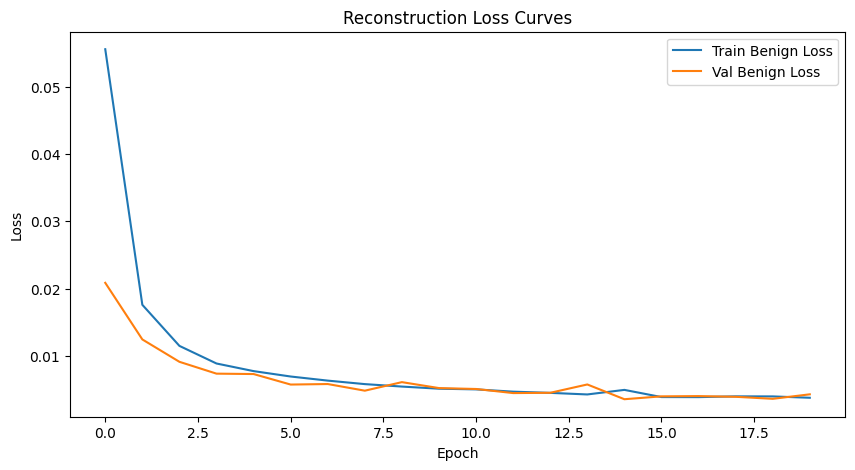

Diagnosis: Neither: Curves stabilized with a healthy gap.


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history['train'], label='Train Benign Loss')
plt.plot(history['val'], label='Val Benign Loss')
plt.title('Reconstruction Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

def diagnose_fit(hist):
    t = hist['train']
    v = hist['val']
    if len(t) < 2: return "Insufficient data"

    final_gap = v[-1] - t[-1]
    val_improvement = v[0] - min(v)

    if val_improvement < 1e-4:
        return "Likely Underfitting: Validation loss barely improved."
    if final_gap > (t[-1] * 0.5):
        return "Likely Overfitting: Significant generalization gap."
    return "Neither: Curves stabilized with a healthy gap."

print(f"Diagnosis: {diagnose_fit(history)}")

## 8. Validation-Only Anomaly Threshold

In [ ]:
def get_reconstruction_scores(loader, model):
    model.eval()
    scores = []
    labels = []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            output = model(batch_x)
            mse = torch.mean((output - batch_x)**2, dim=2).squeeze(1)
            scores.extend(mse.cpu().numpy())
            labels.extend(batch_y.numpy())
    return np.array(scores), np.array(labels)

val_scores, val_y_true = get_reconstruction_scores(val_loader, model)

precision, recall, thresholds = precision_recall_curve(val_y_true, val_scores)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimized Val Threshold: {best_threshold:.6f}")
print(f"Best Val F1-Score: {np.max(f1_scores):.4f}")

Optimized Val Threshold: 0.001724
Best Val F1-Score: 0.7945


In [ ]:
X_test_selected = X_test[features_to_use].copy()

X_test_processed = preprocessor.transform(X_test_selected)

X_test_scaled = scaler.transform(X_test_processed)

print("Test data shape after preprocessing:", X_test_scaled.shape)

test_ds = NetworkFlowDataset(
    X_test_scaled,
    y_test,
    only_benign=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False
)

test_scores, test_y_true = get_reconstruction_scores(
    test_loader,
    model
)

test_y_pred = (test_scores > best_threshold).astype(int)


print("\n" + "=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

print(f"Threshold from validation set: {best_threshold:.6f}")

print("\nClassification Report:")
print(
    classification_report(
        test_y_true,
        test_y_pred,
        target_names=["BENIGN", "ATTACK"],
        digits=4
    )
)

print("Confusion Matrix:")
cm = confusion_matrix(test_y_true, test_y_pred)
print(cm)

test_f1 = f1_score(test_y_true, test_y_pred)
test_roc_auc = roc_auc_score(test_y_true, test_scores)
test_pr_auc = average_precision_score(test_y_true, test_scores)

print(f"\nTest F1-score: {test_f1:.4f}")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")
print(f"Test PR-AUC:   {test_pr_auc:.4f}")

tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_attack = tp / (tp + fp + 1e-8)
recall_attack = tp / (tp + fn + 1e-8)
specificity = tn / (tn + fp + 1e-8)
false_positive_rate = fp / (fp + tn + 1e-8)
false_negative_rate = fn / (fn + tp + 1e-8)

print("\nDetailed Metrics:")
print(f"Accuracy:            {accuracy:.4f}")
print(f"Attack Precision:    {precision_attack:.4f}")
print(f"Attack Recall:       {recall_attack:.4f}")
print(f"Specificity:         {specificity:.4f}")
print(f"False Positive Rate: {false_positive_rate:.4f}")
print(f"False Negative Rate: {false_negative_rate:.4f}")

print("\nPrediction Summary:")
print(f"Total test samples:       {len(test_y_true)}")
print(f"Actual BENIGN samples:    {(test_y_true == 0).sum()}")
print(f"Actual ATTACK samples:    {(test_y_true == 1).sum()}")
print(f"Predicted BENIGN samples: {(test_y_pred == 0).sum()}")
print(f"Predicted ATTACK samples: {(test_y_pred == 1).sum()}")

Test data shape after preprocessing: (45149, 78)

FINAL TEST EVALUATION
Threshold from validation set: 0.001724

Classification Report:
              precision    recall  f1-score   support

      BENIGN     0.7539    0.6237    0.6827     19544
      ATTACK     0.7462    0.8446    0.7924     25605

    accuracy                         0.7490     45149
   macro avg     0.7501    0.7342    0.7375     45149
weighted avg     0.7496    0.7490    0.7449     45149

Confusion Matrix:
[[12190  7354]
 [ 3979 21626]]

Test F1-score: 0.7924
Test ROC-AUC:  0.8273
Test PR-AUC:   0.8853

Detailed Metrics:
Accuracy:            0.7490
Attack Precision:    0.7462
Attack Recall:       0.8446
Specificity:         0.6237
False Positive Rate: 0.3763
False Negative Rate: 0.1554

Prediction Summary:
Total test samples:       45149
Actual BENIGN samples:    19544
Actual ATTACK samples:    25605
Predicted BENIGN samples: 16169
Predicted ATTACK samples: 28980
